In [4]:
import numpy as np
import matplotlib.pyplot as plt

 Функции, используемые в лабораторной работе, их производные и интегралы

In [5]:
def f(x0):
    return np.sin(x0)


def g(x0):
    return 1 / x0


def f_prime(x0):
    return np.cos(x0)


def g_prime(x0):
    return -1 / x0 ** 2


def f_integral(x0):
    return -np.cos(x0)


def g_integral(x0):
    return np.log(abs(x0))

Производные

task 1

In [6]:
#Правая разностная производная
def forward_difference(func: callable, x0, step: float):
    return (func(x0 + step) - func(x0)) / step

#Центральная разностная производная
def central_difference(func: callable, x0, step: float):
    return (func(x0 + step) - func(x0 - step)) / (2 * step)

#Левая разностная производная
def backward_difference(func: callable, x0, step: float):
    return (func(x0) - func(x0 - step)) / step


x1 = 3.14/2
h = 0.1

# 0.50
print("Правая разностная производная:", forward_difference(f, x1, h))

# 0.54
print("Центральная разностная производная:", central_difference(f, x1, h))

# 0.58
print("Левая разностная производная:", backward_difference(f, x1, h))

Правая разностная производная: -0.04916333121654404
Центральная разностная производная: 0.0007950001629963843
Левая разностная производная: 0.050753331542536806


task 2

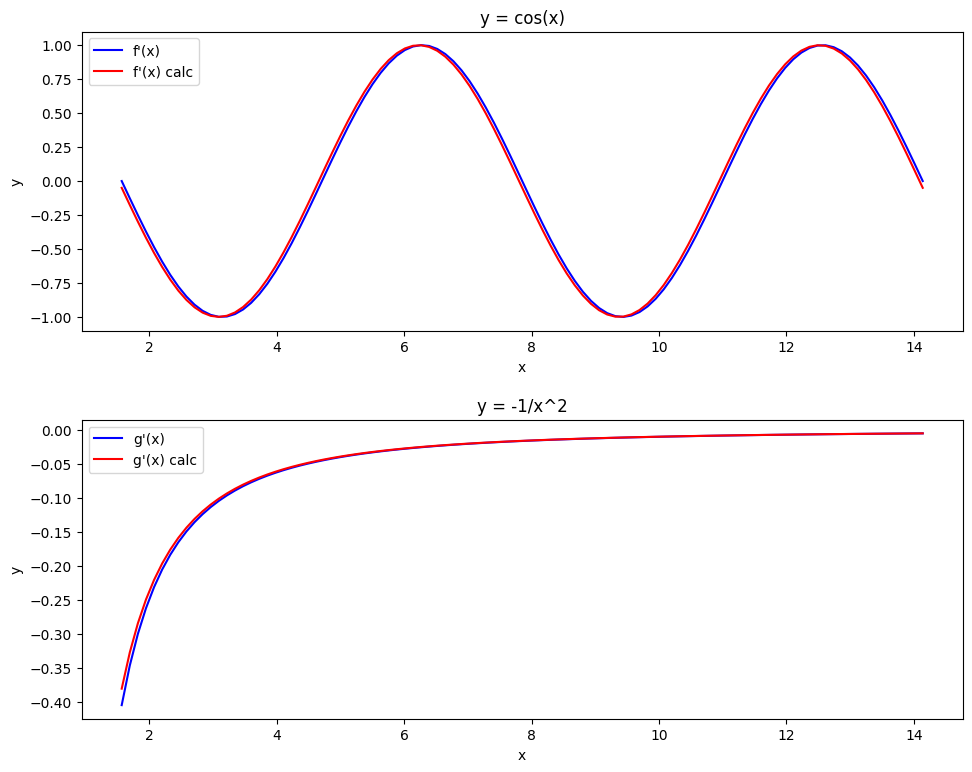

In [7]:
# Определяем точки сетки
x2 = np.linspace(np.pi / 2, 4.5 * np.pi, 100)

# Вычисляем численные производные с шагом h = 0.1
h = 0.1
df_num = forward_difference(f, x2, h)
dg_num = forward_difference(g, x2, h)

# Строим графики
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(x2, f_prime(x2), "b-", label="f'(x)")
plt.plot(x2, df_num, "r-", label="f'(x) calc")
plt.title("y = cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x2, g_prime(x2), "b-", label="g'(x)")
plt.plot(x2, dg_num, "r-", label="g'(x) calc")
plt.title("y = -1/x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout(pad=1.7)
plt.show()

task 3

In [8]:
x3 = np.linspace(0, np.pi, 100)

true_derivatives = f_prime(x3)

dx = x3[1] - x3[0]
numerical_derivatives = forward_difference(f, x3, dx)

std_dev = np.std(true_derivatives - numerical_derivatives)

print("Standard deviation: ", std_dev)

Standard deviation:  0.004964180655537803


task 4

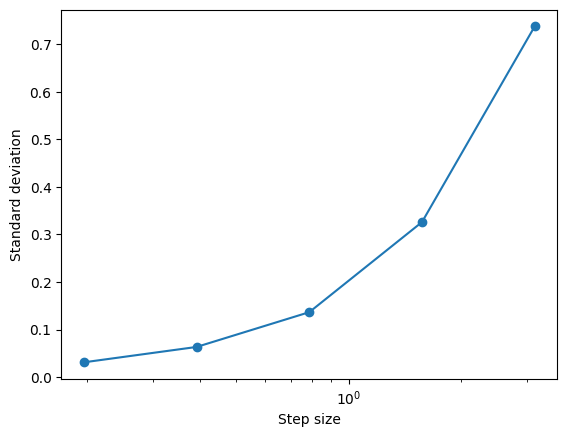

In [9]:
x4 = np.linspace(0, np.pi, 100)

true_derivatives = f_prime(x4)

steps = [np.pi / 2 ** i for i in range(5)]

std_devs = []
for step in steps:
    numerical_derivatives = forward_difference(f, x4, step)
    std_dev = np.std(true_derivatives - numerical_derivatives)
    std_devs.append(std_dev)

plt.plot(steps, std_devs, 'o-')
plt.xscale('log')
plt.xlabel('Step size')
plt.ylabel('Standard deviation')
plt.show()

Интегралы

task 5

In [10]:
def left_rectangles(func: callable, left: float, right: float, step: float) -> float:
    result = 0
    i = 1
    while left + step * i <= right:
        result += step * func(left + step * (i - 1))
        i += 1

    return result


def right_rectangles(func: callable, left: float, right: float, step: float) -> float:
    result = 0
    i = 1
    while left + step * i <= right:
        result += step * func(left + step * i)
        i += 1

    return result


def central_rectangles(func: callable, left: float, right: float, step: float) -> float:
    result = 0
    i = 1
    while left + step * i <= right:
        result += step * func(left + step * (i - 0.5))
        i += 1

    return result


def trapezoid(func: callable, left: float, right: float, step: float) -> float:
    result = 0
    i = 1
    while left + step * i <= right:
        result += 0.5 * step * (func(left + step * (i - 1)) + func(left + step * i))
        i += 1

    return result


def simpson(func: callable, left: float, right: float, step: float) -> float:
    result = 0
    i = 1
    while left + step * i <= right:
        result += 1/6 * step * (func(left + step * (i - 1)) + 4 * func(left + step * (i - 0.5)) + func(left + step * i))
        i += 1

    return result

task 6

In [11]:
def calc_integral(integrated_func: callable, left: float, right: float):
    return integrated_func(right) - integrated_func(left)


xL = np.pi
xR = 5 * np.pi
dx = 4 * np.pi / 100

def print_results(integrated_func: callable, og: callable):
    print("\n")
    print(f"Theoretical value: {calc_integral(integrated_func, xL, xR)}")
    print(f"Value calculated with left rectangles method: {left_rectangles(og, xL, xR, dx)}")
    print(f"Value calculated with right rectangles method: {right_rectangles(og, xL, xR, dx)}")
    print(f"Value calculated with central rectangles method: {central_rectangles(og, xL, xR, dx)}")
    print(f"Value calculated with trapezoids method: {trapezoid(og, xL, xR, dx)}")
    print(f"Value calculated with Simpson's method: {simpson(og, xL, xR, dx)}")


print_results(f_integral, f)
print_results(g_integral, g)



Theoretical value: 0.0
Value calculated with left rectangles method: -0.01574983863265133
Value calculated with right rectangles method: -4.649058915617843e-16
Value calculated with central rectangles method: -0.007890489394735554
Value calculated with trapezoids method: -0.007874919316325106
Value calculated with Simpson's method: -0.007885299368598268


Theoretical value: 1.6094379124341003
Value calculated with left rectangles method: 1.617501375022094
Value calculated with right rectangles method: 1.5855658911511261
Value calculated with central rectangles method: 1.601341802541127
Value calculated with trapezoids method: 1.6015336330866097
Value calculated with Simpson's method: 1.6014057460562874


task 7

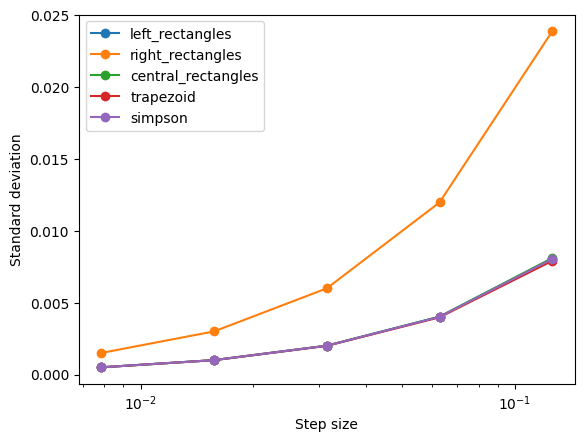

In [12]:
steps = [dx / 2 ** i for i in range(5)]

std_devs = [[0] * len(steps) for i in range(5)]
G = calc_integral(g_integral, xL, xR)

for i, step in enumerate(steps):
    std_devs[0][i] = abs(left_rectangles(g, xL, xR, step) - G)
    std_devs[1][i] = abs(right_rectangles(g, xL, xR, step) - G)
    std_devs[2][i] = abs(central_rectangles(g, xL, xR, step) - G)
    std_devs[3][i] = abs(trapezoid(g, xL, xR, step) - G)
    std_devs[4][i] = abs(simpson(g, xL, xR, step) - G)

funcs = ["left_rectangles", "right_rectangles", "central_rectangles", "trapezoid", "simpson"]
for i in range(5):
    plt.plot(steps, std_devs[i], 'o-', label=funcs[i])

plt.xlabel('Step size')
plt.xscale('log')
plt.ylabel('Standard deviation')
plt.legend()
plt.show()